# Revolution 几何 × NFM-DS T-matrix：对称性笔记

对齐 [`tests/test_revolution_tmatrix.py`](../../../../tests/test_revolution_tmatrix.py)：用 `revolution_geometry`（母线回调 / TypeGeom=4）算 **`T_elem`**，并以 **Axsym-FEM**（`write_revolution_axsym_fem` → `compute_nfmds_tmatrix_axsym_file`）为唯一基线 **`T_axfem`**。

本笔记重点：

1. NFM-DS 下标 ↔ \((\tau,l,m)\) 正交基（仅在球一节详写）
2. 不同旋转体对称性 → \(\lvert T\rvert\) 明暗分布
3. **1×3** 对数色标对比：`|T_elem|` / `|T_axfem|` / `|elem−axfem|`
4. 层内多散射体的**团簇有效 T**（位姿进入装配；见 §8）
5. 用**群论/对称性**串起前面所有 \(\lvert T\rvert\) 图（见 §9）

**运行前提**（见仓库 README）：

```bash
cd simulation_core
source scripts/init-simulation-build-env.sh
source 3rdparty/infrastructure/.venv/bin/activate
export LD_LIBRARY_PATH="$PWD/build:${LD_LIBRARY_PATH:-}"
export PYTHONPATH="$PWD/build:$PWD/simulation_plugins:${PYTHONPATH:-}"
jupyter notebook assets/ipynb/simulation/tmatrix/revolution_axsym_tmatrix_notes.ipynb
```

参数：`NRANK=4`，\(\lambda=2\pi\)，`n_med=1`，`n_rel=1.5`，粒子尺度 \(O(1)\) ⇒ \(x\sim1\)。


In [1]:
%matplotlib inline
import os
import sys
import math
import tempfile
from pathlib import Path

os.environ["SAVE_TO_FILE"] = "0"

# repo root = .../simulation_core
HERE = Path.cwd().resolve()
for p in [HERE, *HERE.parents]:
    if (p / "scripts" / "init-simulation-build-env.sh").exists() and (p / "build").exists():
        ROOT = p
        break
else:
    ROOT = HERE

sys.path[:0] = [
    str(ROOT / "build"),
    str(ROOT / "simulation_plugins"),
    str(ROOT / "3rdparty" / "nfmds" / "tools"),
    str(ROOT / "3rdparty" / "infrastructure" / "py_core_plugins"),
]
os.environ["LD_LIBRARY_PATH"] = str(ROOT / "build") + os.pathsep + os.environ.get("LD_LIBRARY_PATH", "")

import numpy as np
import matplotlib.pyplot as plt
import simulation
import layer_visualizer as lv

from nfmds_smuthi_index import (
    nmax_from_nrank_mrank,
    single_index_to_multi_nfmds,
)


PI = math.pi
WL = 2.0 * PI
N_MED = 1.0
N_REL = 1.5 + 0j
NRANK = 4
NMAX = nmax_from_nrank_mrank(NRANK, NRANK)
SIDE = 2 * NMAX
LOG_FLOOR = 1e-30

print(f"ROOT={ROOT}")
print(f"NRANK={NRANK} Nmax={NMAX} T side={SIDE}")


def _mat():
    return simulation.share_material_s(simulation.material_s.from_epsilon((N_REL**2), "Si"))


def _rel_err(a, b) -> float:
    a = np.asarray(a)
    b = np.asarray(b)
    mask = np.isfinite(a) & np.isfinite(b)
    if not np.any(mask):
        return float("inf")
    den = max(float(np.linalg.norm(b[mask])), 1e-30)
    return float(np.linalg.norm(a[mask] - b[mask]) / den)


def _spheroid_eval(a: float, b: float):
    def eval_cb(iparam: int, param: float):
        e = a / b
        e2 = e * e
        th = float(param)
        tamp = math.cos(th) ** 2 + math.sin(th) ** 2 * e2
        inv = 1.0 / math.sqrt(tamp)
        r = a * inv
        dr = -a * math.cos(th) * math.sin(th) * (e2 - 1.0) * inv / tamp
        s = math.sqrt(r * r + dr * dr)
        dA = s * r * math.sin(th)
        return (r, th, 0.0, dA, r / s, -dr / s, 0.0)
    return eval_cb


def _cylinder_eval(a: float, b: float):
    def eval_cb(iparam: int, param: float):
        th = float(param)
        if iparam == 1:
            invc = 1.0 / math.cos(th)
            r = a * invc
            dr = a * math.sin(th) * invc * invc
        elif iparam == 2:
            invs = 1.0 / math.sin(th)
            r = b * invs
            dr = -b * math.cos(th) * invs * invs
        else:
            invc = 1.0 / math.cos(th)
            r = -a * invc
            dr = -a * math.sin(th) * invc * invc
        s = math.sqrt(r * r + dr * dr)
        dA = s * r * math.sin(th)
        return (r, th, 0.0, dA, r / s, -dr / s, 0.0)
    return eval_cb


def _make_rev(nparam, breaks, r_circ, eval_cb, nint=120):
    return simulation.make_revolution_shape_s(
        nparam, breaks, r_circ, eval_cb, [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], _mat(), nint
    )


def _t_elem(shape):
    return np.asarray(simulation.compute_nfmds_tmatrix_s(shape, WL, N_MED + 0j, NRANK))


def _t_axfem(shape, tmp=None):
    tmp = Path(tmp or tempfile.mkdtemp(prefix="rax_", dir="/tmp"))
    fem = tmp / "ax.fem"
    fem_path = str(fem.resolve())
    if len(fem_path) > 80:
        fem = Path(tempfile.mkdtemp(prefix="rax_", dir="/tmp")) / "ax.fem"
        fem_path = str(fem)
    lv.write_revolution_axsym_fem(shape, fem_path, n_per_segment=48)
    return np.asarray(
        simulation.compute_nfmds_tmatrix_axsym_file_s(
            WL, N_MED, N_REL, 1, 1, [1.0, 1.0], NRANK, fem_path
        )
    )


def plot_geometry(shape, title: str):
    # show=False: avoid filmstack closing the figure when SAVE_TO_FILE is off
    ax = lv.plot_layer_geometries_3d([shape], title=title, show=False)
    plt.show()
    return ax


def plot_t_compare_log(T_elem, T_ax, title: str = ""):
    # 1x3 log10 |T|: elem / axfem / |diff|
    fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.8), constrained_layout=True)
    Ae = np.abs(np.nan_to_num(T_elem, nan=0.0, posinf=0.0, neginf=0.0))
    Aa = np.abs(np.nan_to_num(T_ax, nan=0.0, posinf=0.0, neginf=0.0))
    De = np.abs(np.nan_to_num(T_elem - T_ax, nan=0.0, posinf=0.0, neginf=0.0))
    Le = np.log10(np.maximum(Ae, LOG_FLOOR))
    La = np.log10(np.maximum(Aa, LOG_FLOOR))
    Ld = np.log10(np.maximum(De, LOG_FLOOR))
    vmin = math.log10(LOG_FLOOR)
    vmax = max(float(Le.max()), float(La.max()), vmin + 1e-12)
    vmax_d = max(float(Ld.max()), vmin + 1e-12)
    panels = [
        (axes[0], Le, "|T_elem| (log10)", vmin, vmax),
        (axes[1], La, "|T_axfem| (log10)", vmin, vmax),
        (axes[2], Ld, "|elem-axfem| (log10)", vmin, vmax_d),
    ]
    for ax, data, ttl, vn, vx in panels:
        im = ax.imshow(data, origin="lower", aspect="equal", vmin=vn, vmax=vx)
        ax.set_title(ttl)
        ax.axhline(NMAX - 0.5, color="w", lw=0.6, alpha=0.5)
        ax.axvline(NMAX - 0.5, color="w", lw=0.6, alpha=0.5)
        fig.colorbar(im, ax=ax, fraction=0.046)
    if title:
        fig.suptitle(title)
    plt.show()
    return fig


def run_case(case_id: str, shape):
    print(f"=== {case_id}: geometry ===", flush=True)
    plot_geometry(shape, f"revolution_{case_id}_geom")
    print(f"=== {case_id}: T_elem / T_axfem ===", flush=True)
    Te = _t_elem(shape)
    Ta = _t_axfem(shape)
    ea = _rel_err(Te, Ta)
    print(f"{case_id}: err_axfem={ea:.3e}  shape={Te.shape}", flush=True)
    plot_t_compare_log(Te, Ta, title=f"{case_id}: log |T|")
    return Te, Ta, ea

ROOT=/home/like/repos/simulation_toykits/simulation_core
NRANK=4 Nmax=24 T side=48


## 0. NFM-DS 下标 ↔ 正交基（读图必备）

`nrank=4` ⇒ \(N_{\max}=n_{\mathrm{rank}}(n_{\mathrm{rank}}+2)=24\)，T 为 \(2N_{\max}=48\) 维。

### 外层四大块（\(\tau\)）

| 下标 | \(\tau\) | SVWF | 常当作 |
|------|----------|------|--------|
| `0 … 23` | 0 | **M**（磁型） | s / TE |
| `24 … 47` | 1 | **N**（电型） | p / TM |

```text
              入射 j →
           M(0..23)      N(24..47)
散     ┌─────────────┬─────────────┐
射  M  │  MM ≈ ss    │  MN ≈ sp    │
i↓     ├─────────────┼─────────────┤
   N   │  NM ≈ ps    │  NN ≈ pp    │
       └─────────────┴─────────────┘
```

`T[i,j]` = 入射模式 \(j\) → 散射模式 \(i\)。线性色标上三个最亮点几乎都在 **NN（pp）** 对角上。

### 半块内：先 \(m\)，再 \(l\)

与 `appendtotmat` / [`nfmds_smuthi_index.py`](../../../../3rdparty/nfmds/tools/nfmds_smuthi_index.py) 的 **`single_index_to_multi_nfmds`** 一致（`Mrank=Nrank`；查 flat 下标请正向扫描，勿用有 bug 的 `multi_index_to_single_nfmds`）：

```text
半块下标 0..23（每个 τ）：
  0..3:   m=0,  l=1..4
  4..7:   m=+1, l=1..4
  8..11:  m=-1, l=1..4
 12..14:  m=+2, l=2..4
 15..17:  m=-2, l=2..4
 18..19:  m=+3, l=3..4
 20..21:  m=-3, l=3..4
 22:      m=+4, l=4
 23:      m=-4, l=4
```


### \(z=0\) 镜面对称 → 块内「明暗相间」

轴对称只保证：只耦合同一个 \(m\)。若几何还关于赤道面 \(z\to -z\) 对称（球、椭球、两端对称截断、有限圆柱等），多极在镜射下有确定宇称（大致由 \((-1)^l\)，再叠 \(\tau\)）。散射体不变 ⇒ **不同宇称通道互不耦合**。

在固定 \(m\) 的 \(l\times l'\) 小块里（\(l=|m|,\ldots,n_{\mathrm{rank}}\)），因此出现棋盘格：

- **同宇称**（同奇或同偶 \(l,l'\)）：可以非零
- **异宇称**：应严格为 0（数值上常到 \(10^{-17}\)）

例：\(m=+1\)、\(l=1..4\) 的局部块示意

```text
l\l'   1      2      3      4
1     ■      □      ■      □
2     □      ■      □      ■
3     ■      □      ■      □
4     □      ■      □      ■
```

（■ = 允许，□ = 禁戒。）

在 \(x\sim1\)、软介电时 **奇多极（尤其电偶极 \(l=1\)）远强于偶多极**，所以棋盘格里往往是 **第 1、3 格（奇 \(l\)）更亮，第 2、4 格（偶 \(l\)）更暗**——这是偶极主导 + 宇称选择定则，不是「奇数 \(m\) 特别大」。方位角上仍是 \(m=0,\pm1\)（偶极）最强；\(|m|=3\) 通常小于 \(|m|=2\)。

破坏 \(z=0\) 对称（如一端截断、柱+单侧半球拱）后，异宇称元被填亮，棋盘格糊掉；轴对称的 \(m\neq m'\) 禁戒仍在。

### 为何用 \(\log_{10}|T|\)

\(x\sim1\) 时电偶极远强于高阶；**线性**色标几乎只剩偶极黄点。对数才能看见：\(m\)-块稀疏、sp/ps 交叉、以及 \(m=0\) 的 TE/TM 解耦。

In [2]:
# 打印半块索引表 + 标出电偶极三通道
# 注意：本仓库 multi_index_to_single_nfmds 对 m≠0 有 off-by 问题，
# 查下标请用 single_index_to_multi_nfmds 正向扫描。

def find_flat(tau, l, m):
    for i in range(SIDE):
        t, ll, mm = single_index_to_multi_nfmds(i, NRANK, NRANK)
        if (t, ll, mm) == (tau, l, m):
            return i
    raise KeyError((tau, l, m))


print(f"{'idx':>4} {'tau':>3} {'l':>2} {'m':>3}  note")
print("-" * 40)
for idx in range(SIDE):
    tau, l, m = single_index_to_multi_nfmds(idx, NRANK, NRANK)
    note = ""
    if tau == 1 and l == 1 and m in (0, 1, -1):
        note = f"  <- electric dipole N(l=1,m={m:+d})  pixel ({idx},{idx})"
    if tau == 0 and l == 1 and m in (0, 1, -1):
        note = f"  <- magnetic dipole M(l=1,m={m:+d})"
    if idx < 12 or note:
        print(f"{idx:4d} {tau:3d} {l:2d} {m:3d}{note}")
    elif idx == 12:
        print(" ...")

for m in (0, 1, -1):
    i = find_flat(1, 1, m)
    print(f"N(l=1,m={m:+d}) -> flat index {i}")


 idx tau  l   m  note
----------------------------------------
   0   0  1   0  <- magnetic dipole M(l=1,m=+0)
   1   0  2   0
   2   0  3   0
   3   0  4   0
   4   0  1   1  <- magnetic dipole M(l=1,m=+1)
   5   0  2   1
   6   0  3   1
   7   0  4   1
   8   0  1  -1  <- magnetic dipole M(l=1,m=-1)
   9   0  2  -1
  10   0  3  -1
  11   0  4  -1
 ...
  24   1  1   0  <- electric dipole N(l=1,m=+0)  pixel (24,24)
  28   1  1   1  <- electric dipole N(l=1,m=+1)  pixel (28,28)
  32   1  1  -1  <- electric dipole N(l=1,m=-1)  pixel (32,32)
N(l=1,m=+0) -> flat index 24
N(l=1,m=+1) -> flat index 28
N(l=1,m=-1) -> flat index 32


## 1. Sphere（球）

母线：单段 \(\theta\in[0,\pi]\)，\(a=b=R=1\)（即球）。球对称 ⇒ T 近对角；整块 sp/ps≈0；\(m=0,\pm1\) 的电偶极对角元几乎简并。

三黄点固定在：

| 像素 | 模式 |
|------|------|
| `T[24,24]` | \(N(l=1,m=0)\) |
| `T[28,28]` | \(N(l=1,m=+1)\) |
| `T[32,32]` | \(N(l=1,m=-1)\) |

=== sphere: geometry ===


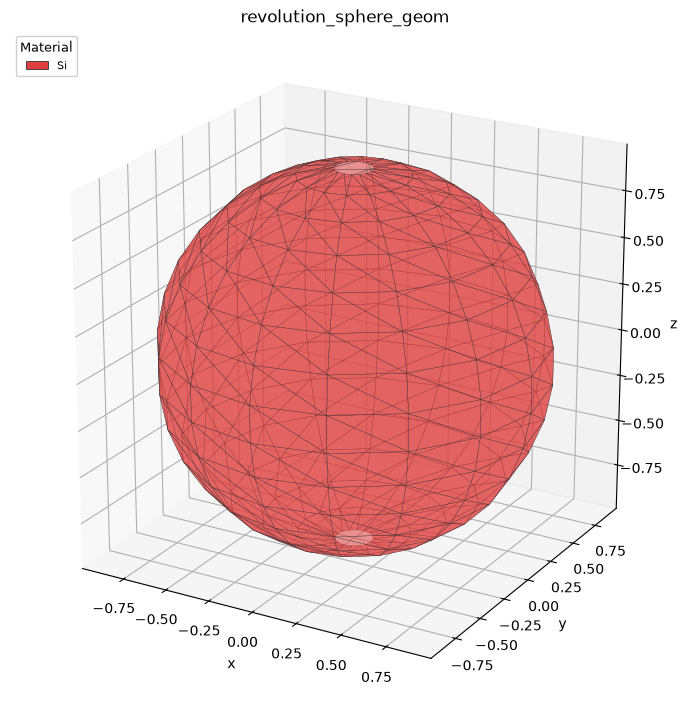

=== sphere: T_elem / T_axfem ===



sphere: err_axfem=2.924e-04  shape=(48, 48)


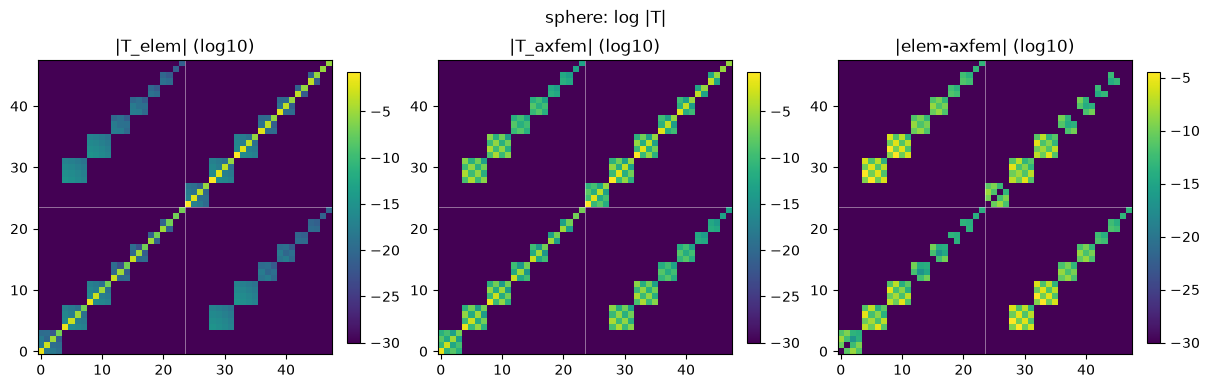

elem vs builtin sphere: 7.249e-15
|T_NN[24,24]| = 0.186742  (N l=1 m=+0)
|T_NN[28,28]| = 0.186742  (N l=1 m=+1)
|T_NN[32,32]| = 0.186742  (N l=1 m=-1)


In [3]:
R = 1.0
shape_sphere = _make_rev(1, [0.0, PI], R, _spheroid_eval(R, R))
Te_sph, Ta_sph, ea_sph = run_case("sphere", shape_sphere)

sph = simulation.make_sphere_shape_s(R, [0, 0, 0], [0, 0, 0], _mat())
Tb = np.asarray(simulation.compute_nfmds_tmatrix_s(sph, WL, N_MED + 0j, NRANK))
print(f"elem vs builtin sphere: {_rel_err(Te_sph, Tb):.3e}")

for m in (0, 1, -1):
    i = find_flat(1, 1, m)
    print(f"|T_NN[{i},{i}]| = {abs(Te_sph[i, i]):.6f}  (N l=1 m={m:+d})")


### 球：对称性读图

- **四大块**：ss/pp（MM/NN）沿对角亮；**整块 sp/ps（MN/NM）≈黑**——球不混 \(\tau\)。
- **半块内**：只见同 \((l,m)\) 对角；不同 \(m\) 之间无耦合（旋转对称 + 球对称）。
- **\(z=0\) 对称**：每个 \(m\)-块内异宇称 \(l\leftrightarrow l'\) 为 0；球更强——不同 \(l\) 也不混，只剩对角。
- **三黄点**：电偶极 \(N(l=1)\) 的 \(m=0,\pm1\) 幅值几乎相等（简并）。
- **axfem**：与 elem 同走 TAXSYM，对数图几乎重合，diff 列接近色标底噪。


## 2. Spheroid（旋转椭球）

\(a=1,\,b=0.6\)：轴对称非球。选择定则：只耦合相同 \(m\)；**\(m=0\) 时 sp/ps 严格为 0**（TE/TM 解耦）；\(m\neq0\) 可有 M↔N。

=== spheroid: geometry ===


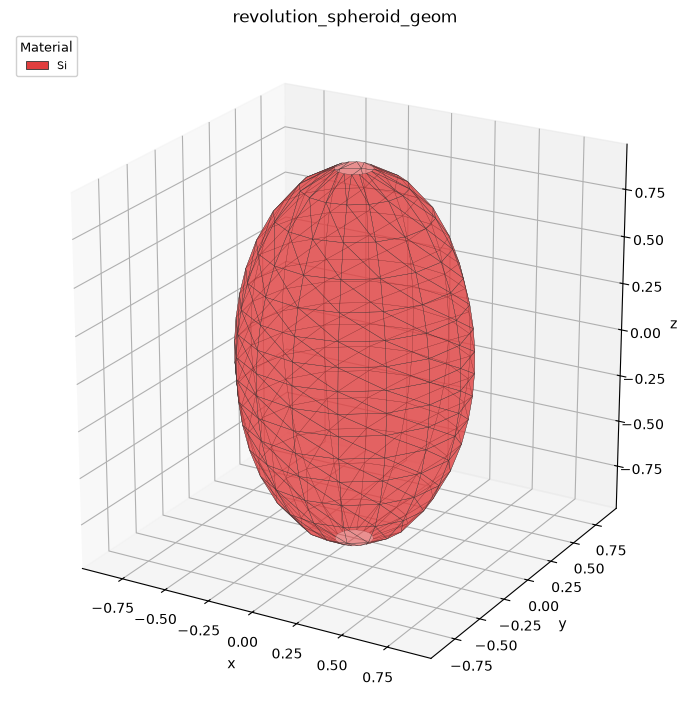

=== spheroid: T_elem / T_axfem ===



spheroid: err_axfem=7.613e-04  shape=(48, 48)


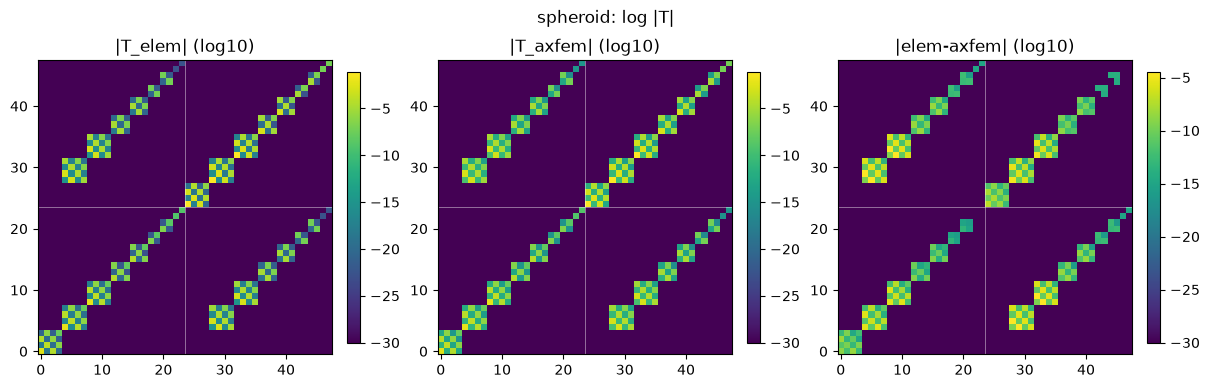

elem vs builtin spheroid: 1.066e-07
max |MN| on m=0 block (0..3): 0.000e+00
max |MN| on m=+1 block (4..7): 1.519e-03


In [4]:
a, b = 1.0, 0.6
shape_spheroid = _make_rev(1, [0.0, PI], max(a, b), _spheroid_eval(a, b))
Te_ell, Ta_ell, ea_ell = run_case("spheroid", shape_spheroid)

sp = simulation.make_spheroid_shape_s(a, b, [0, 0, 0], [0, 0, 0], _mat())
Tb = np.asarray(simulation.compute_nfmds_tmatrix_s(sp, WL, N_MED + 0j, NRANK))
print(f"elem vs builtin spheroid: {_rel_err(Te_ell, Tb):.3e}")

MN = np.abs(Te_ell[0:NMAX, NMAX:2 * NMAX])
print(f"max |MN| on m=0 block (0..3): {MN[0:4, 0:4].max():.3e}")
print(f"max |MN| on m=+1 block (4..7): {MN[4:8, 4:8].max():.3e}")

### 椭球：对称性读图

- **\(m\)-块稀疏**：非对角 \(m\neq m'\) 仍接近黑（轴对称）。
- **MN/NM**：\(m=0\) 小块仍黑；\(m=\pm1\) 可出现交叉极化亮点。
- **\(z=0\) 棋盘格**：同 \(m\) 块内奇–偶 \(l\) 耦合≈0；奇–奇子块（含偶极）明显亮于偶–偶。
- **简并劈裂**：`T[24,24]`（\(m=0\)）与 `T[28,28]`/`T[32,32]`（\(\lvert m\rvert=1\)）数值分开——球简并被拉长破坏。
- axfem ≈ elem。


In [5]:
# 椭球：打印 NN 块内 m=+1 的 |T|（l=1..4），对照宇称棋盘格
def _m_plus1_slice():
    # half-block: m=0 uses 0..3; m=+1 uses 4..7
    return slice(4, 8)

sub = np.abs(Te_ell[NMAX:, NMAX:][_m_plus1_slice(), _m_plus1_slice()])
print("spheroid |NN| m=+1, l=1..4:")
print(np.array2string(sub, precision=4, suppress_small=True))
same = [sub[i, j] for i in range(4) for j in range(4) if (i % 2) == (j % 2)]
opp = [sub[i, j] for i in range(4) for j in range(4) if (i % 2) != (j % 2)]
print(f"same-parity mean={np.mean(same):.3e}  opp-parity mean={np.mean(opp):.3e}")


spheroid |NN| m=+1, l=1..4:
[[0.0646 0.     0.0007 0.    ]
 [0.     0.0026 0.     0.    ]
 [0.0007 0.     0.0001 0.    ]
 [0.     0.     0.     0.    ]]
same-parity mean=8.579e-03  opp-parity mean=2.630e-17


## 3. Cylinder（有限圆柱）

\(a=0.8\)（半高）、\(b=0.5\)（半径）；三段母线：顶盖 / 侧壁 / 底盖。仍是绕 \(z\) 轴的旋转体，选择定则同椭球；块内 \(l\)–\(l'\) 耦合往往比光滑椭球更丰。


=== cylinder: geometry ===


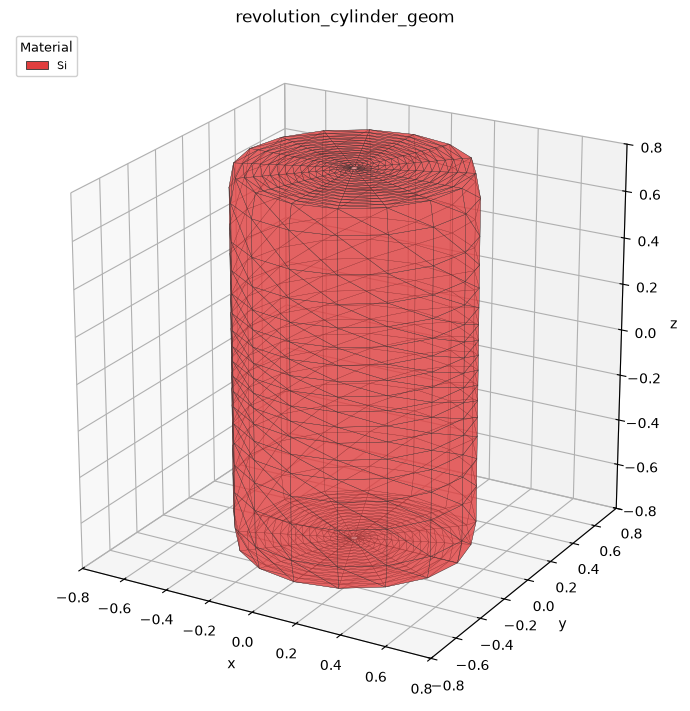

=== cylinder: T_elem / T_axfem ===



cylinder: err_axfem=4.717e-04  shape=(48, 48)


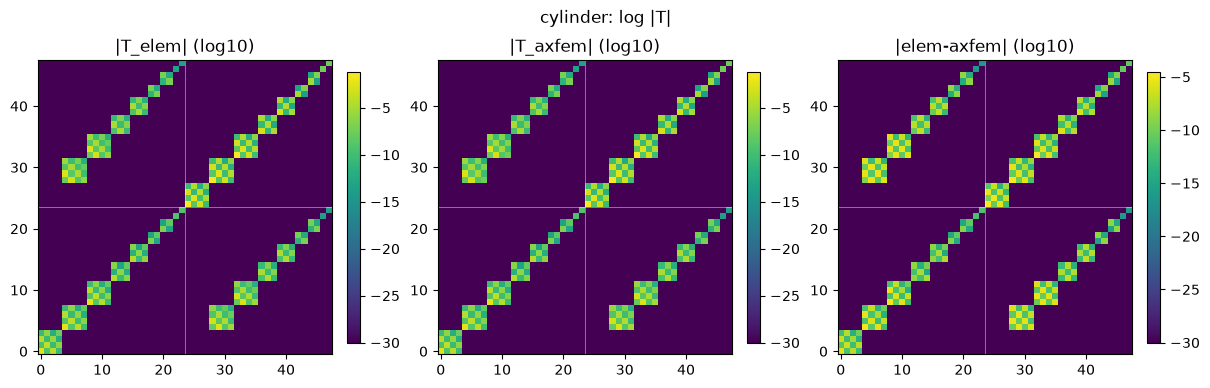

elem vs builtin cylinder: 2.920e-07


In [6]:
a, b = 0.8, 0.5
th0 = math.atan(b / a)
shape_cyl = _make_rev(3, [0.0, th0, PI - th0, PI], math.hypot(a, b), _cylinder_eval(a, b))
Te_cyl, Ta_cyl, ea_cyl = run_case("cylinder", shape_cyl)

cy = simulation.make_finite_cylinder_shape_s(b, 2 * a, [0, 0, 0], [0, 0, 0], _mat())
Tb = np.asarray(simulation.compute_nfmds_tmatrix_s(cy, WL, N_MED + 0j, NRANK))
print(f"elem vs builtin cylinder: {_rel_err(Te_cyl, Tb):.3e}")

### 圆柱：对称性读图

- 仍见清晰的 \(m\)-块网格与 \(m=0\) 的 sp 解耦。
- **上下对称**（顶底盖对称）⇒ 块内 \(l\)-宇称棋盘格仍在；棱边让同宇称的高阶 / \(l\)–\(l'\) 耦合更丰，对数图对角带比球更「胖」。
- axfem（密采样 1D FEM）与 elem 仍应对齐。


## 4. Truncated sphere（双端截球）

\(R=1\)，半高 \(h/2=0.6\)：底/顶平面 + 中间球面弧。仍轴对称；截断破坏球简并，图案更接近圆柱类。

=== trunc_sphere: geometry ===


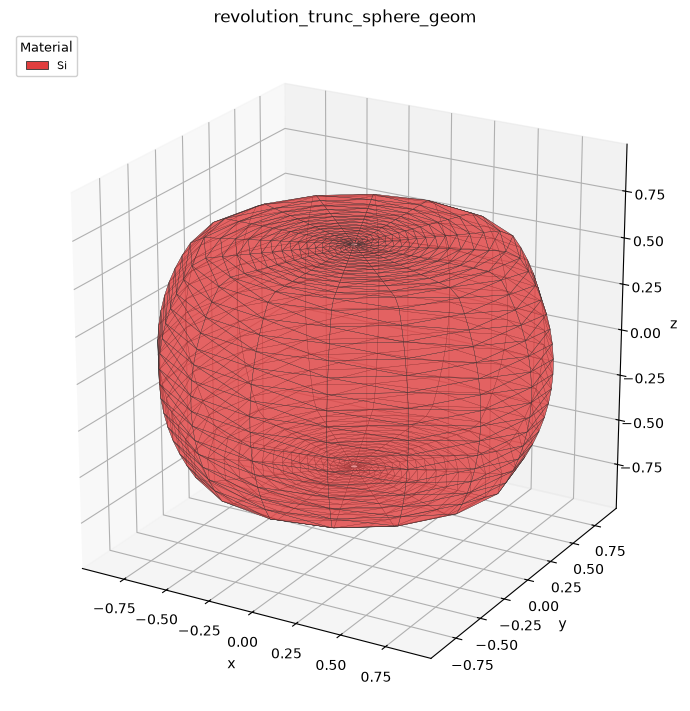

=== trunc_sphere: T_elem / T_axfem ===



trunc_sphere: err_axfem=1.719e-04  shape=(48, 48)


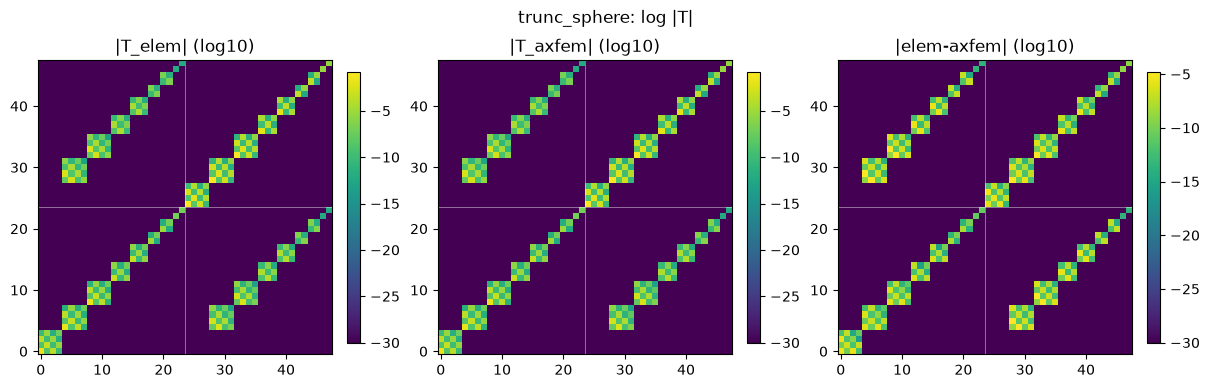

In [7]:
R, h = 1.0, 1.2
half = 0.5 * h
th_e = math.acos(half / R)

def trunc_sphere_eval(iparam, param):
    th = float(param)
    if iparam == 1:  # bottom flat
        invc = 1.0 / math.cos(th)
        r = half * invc
        dr = half * math.sin(th) * invc * invc
    elif iparam == 2:  # sphere arc
        r = R
        dr = 0.0
    else:  # top flat
        invc = 1.0 / math.cos(th)
        r = -half * invc
        dr = -half * math.sin(th) * invc * invc
    s = math.sqrt(r * r + dr * dr)
    dA = s * r * math.sin(th)
    return (r, th, 0.0, dA, r / s, -dr / s, 0.0)

shape_ts = _make_rev(3, [0.0, th_e, PI - th_e, PI], R, trunc_sphere_eval)
Te_ts, Ta_ts, ea_ts = run_case("trunc_sphere", shape_ts)

### 截球：对称性读图

- 旋转体选择定则仍成立：只耦合同方位角指标 \(m\)（\(m\neq m'\) 发黑）。
- **两端对称截断**保留 \(z=0\) 镜面对称 ⇒ \(m\)-块内仍应明暗相间（异宇称禁戒）。
- 相对完整球：\(m=0\) 与 \(\lvert m\rvert=1\) 偶极对角分开；sp 在 \(m\neq0\) 可亮。


## 5. One-end truncated spheroid（一端截断椭球）

\(a=1,\,b=0.7\)，上端在 \(z=z_{\mathrm{cut}}=0.4\) 截平。两段母线：平面盖 + 剩余椭球弧。

th_cut=1.0181
=== trunc_spheroid: geometry ===


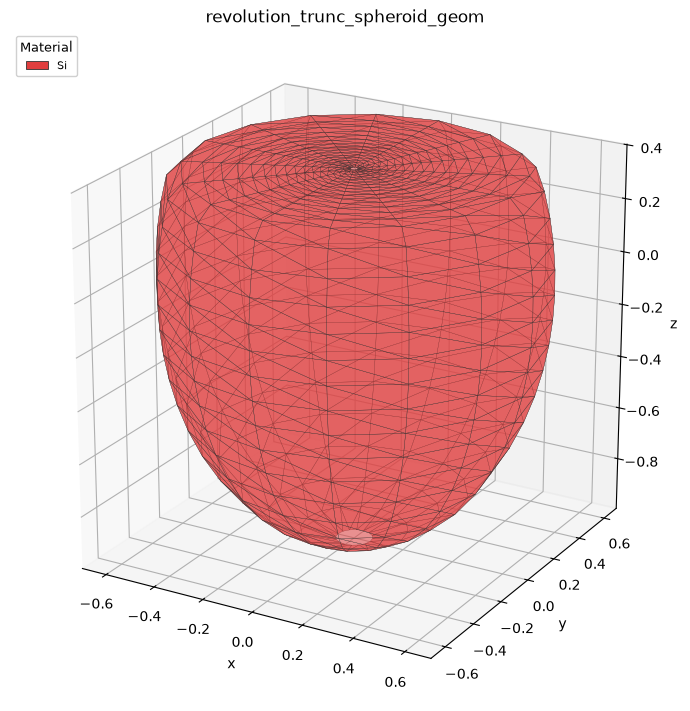

=== trunc_spheroid: T_elem / T_axfem ===



trunc_spheroid: err_axfem=7.218e-04  shape=(48, 48)


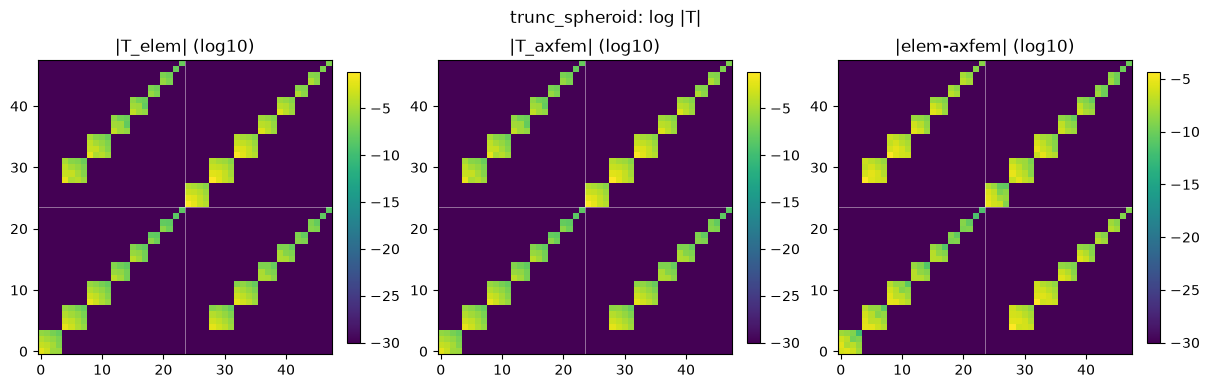

In [5]:
a, b = 1.0, 0.7
zcut = 0.4
ev = _spheroid_eval(a, b)

def find_th_cut():
    for th in np.linspace(0.05, PI - 0.05, 400):
        r, thv, *_ = ev(1, float(th))
        if r * math.cos(thv) <= zcut:
            return float(th)
    return PI / 3

th_c = find_th_cut()

def trunc_spheroid_eval(iparam, param):
    th = float(param)
    if iparam == 1:  # flat cap at z=zcut
        invc = 1.0 / math.cos(th)
        r = zcut * invc
        dr = zcut * math.sin(th) * invc * invc
        s = math.sqrt(r * r + dr * dr)
        dA = s * r * math.sin(th)
        return (r, th, 0.0, dA, r / s, -dr / s, 0.0)
    return ev(1, th)

shape_tse = _make_rev(2, [0.0, th_c, PI], a, trunc_spheroid_eval)
print(f"th_cut={th_c:.4f}")
Te_tse, Ta_tse, ea_tse = run_case("trunc_spheroid", shape_tse)

### 一端截椭球：对称性读图

- 仍是旋转体：\(m\)-块结构 + \(m=0\) TE/TM 解耦。
- **破坏 \(z=0\) 对称**：上下不对称 ⇒ 异宇称 \(l\leftrightarrow l'\) 不再严格为 0，棋盘格被填亮（对照椭球/双端截球）。
- \(m=0\) 与 \(\lvert m\rvert=1\) 的相对权重会变，但不会填满禁戒的 \(m\neq m'\) 元。


In [9]:
# 一端截断：同一 m=+1 切片——异宇称不再≈0
sub = np.abs(Te_tse[NMAX:, NMAX:][4:8, 4:8])
print("trunc_spheroid (one-end) |NN| m=+1, l=1..4:")
print(np.array2string(sub, precision=4, suppress_small=True))
same = [sub[i, j] for i in range(4) for j in range(4) if (i % 2) == (j % 2)]
opp = [sub[i, j] for i in range(4) for j in range(4) if (i % 2) != (j % 2)]
print(f"same-parity mean={np.mean(same):.3e}  opp-parity mean={np.mean(opp):.3e}")


trunc_spheroid (one-end) |NN| m=+1, l=1..4:
[[0.0741 0.004  0.0002 0.    ]
 [0.004  0.0025 0.0002 0.    ]
 [0.0003 0.0002 0.     0.    ]
 [0.     0.     0.     0.    ]]
same-parity mean=9.655e-03  opp-parity mean=1.059e-03


## 6. Arch：圆柱 + 顶半球

底平面 + 柱壁 + 顶半球（关于原点星形）。\(a=0.5\)（半高）、\(b=R=0.4\)。

=== arch_cyl_hem: geometry ===


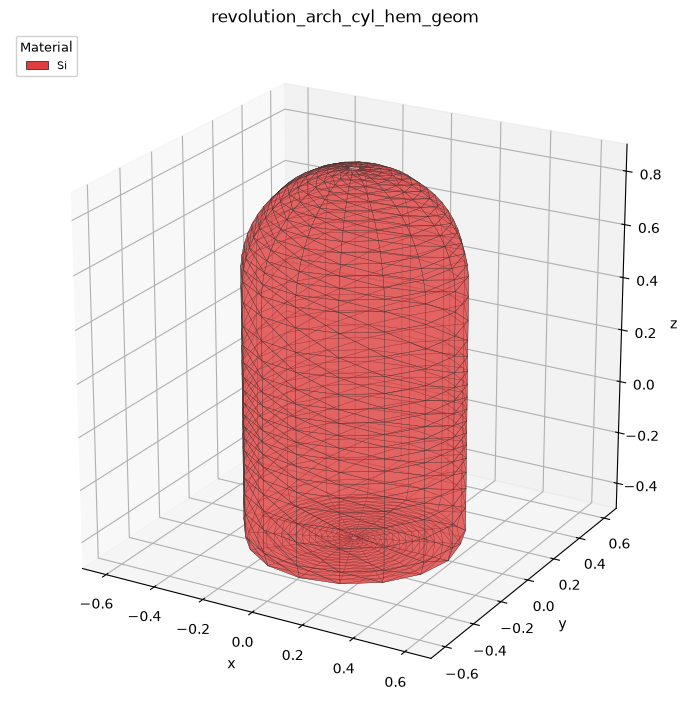

=== arch_cyl_hem: T_elem / T_axfem ===



arch_cyl_hem: err_axfem=5.842e-04  shape=(48, 48)


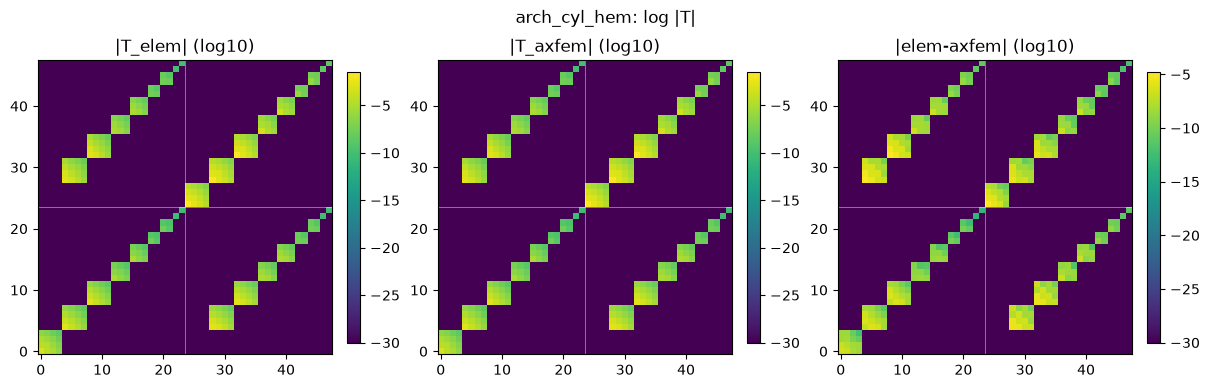

In [10]:
a, b, R = 0.5, 0.4, 0.4
th0 = math.atan(b / a)

def arch_eval(iparam, param):
    th = float(param)
    if iparam == 1:
        # top hemisphere centered at z=+a
        ca = math.cos(th)
        disc = max((a * ca) ** 2 - (a * a - R * R), 0.0)
        r = a * ca + math.sqrt(disc)
        dth = 1e-6
        ca2 = math.cos(th + dth)
        disc2 = max((a * ca2) ** 2 - (a * a - R * R), 0.0)
        dr = (a * ca2 + math.sqrt(disc2) - r) / dth
    elif iparam == 2:
        invs = 1.0 / math.sin(th)
        r = b * invs
        dr = -b * math.cos(th) * invs * invs
    else:
        invc = 1.0 / math.cos(th)
        r = -a * invc
        dr = -a * math.sin(th) * invc * invc
    s = math.sqrt(r * r + dr * dr)
    dA = s * r * math.sin(th)
    return (r, th, 0.0, dA, r / s, -dr / s, 0.0)

shape_arch = _make_rev(3, [0.0, th0, PI - th0, PI], a + R, arch_eval)
Te_arch, Ta_arch, ea_arch = run_case("arch_cyl_hem", shape_arch)

### 拱门：对称性读图

- 仍是旋转体：电偶极主导 + 可见 \(m\neq0\) 交叉极化；\(m=0\) 的 sp 仍应接近 0。
- **无 \(z=0\) 对称**（底平、顶半球）⇒ 块内异宇称可非零，棋盘格不如椭球干净。
- 几何更「棱角」，对数图上块内结构更丰富，但 axfem 基线应对齐 elem。


## 7. 收束：对称性 → T 特征

| 几何类 | 典型 T 特征 |
|--------|-------------|
| **球** | 近对角；整块 sp/ps≈0；\(m=0,\pm1\) 电偶极几乎一样亮 |
| **轴对称旋转体**（绕 \(z\) 转一圈不变） | 只耦合同 \(m\)；**\(m=0\) 时 sp/ps=0**；\(m\neq0\) 可有交叉极化；球的三通道简并被拉开 |
| **再加 \(z=0\) 上下对称** | 同 \(m\) 内奇偶阶耦合≈0 ⇒ **明暗相间棋盘格**；奇数阶往往更亮 |
| **打破上下对称**（一端截断 / 拱门） | \(m\neq m'\) 仍暗；棋盘格糊掉 |
| **axfem 对照** | 与前面的 `T_elem` 对数图几乎重合 |
| **多个粒子组成的团簇**（§8） | 单粒子那套“只耦合同 \(m\)”不再成立；\(m\neq m'\) 可以发亮；图案跟着摆放对称性走 |

接口约束（测试 `missing_eval`）：非 `revolution` 形状没有母线回调时，`layer_visualizer` 采样/写 FEM 会直接 raise——几何必须带可调用 `eval`。

进一步查下标：[`3rdparty/nfmds/tools/nfmds_smuthi_index.py`](../../../../3rdparty/nfmds/tools/nfmds_smuthi_index.py)；回归：[`tests/test_revolution_tmatrix.py`](../../../../tests/test_revolution_tmatrix.py)。

更系统的对称性阶梯见 **§9（群论视角）**。


In [11]:
summary = [
    ("sphere", ea_sph),
    ("spheroid", ea_ell),
    ("cylinder", ea_cyl),
    ("trunc_sphere", ea_ts),
    ("trunc_spheroid", ea_tse),
    ("arch_cyl_hem", ea_arch),
]
print(f"{'case':<16} {'err_axfem':>12}")
for name, ea in summary:
    print(f"{name:<16} {ea:12.3e}")

case                err_axfem
sphere              2.924e-04
spheroid            7.613e-04
cylinder            4.717e-04
trunc_sphere        1.719e-04
trunc_spheroid      7.218e-04
arch_cyl_hem        5.842e-04


## 8. 层有效 T：位姿与团簇

前面各节算的是**单个粒子、在自己局部坐标系里的 T**：位置和姿态不参与。

如果一层里放了多个 3D 粒子，`compute_nfmds_tmatrix_layer` 会按每个粒子的位置/姿态，把各自的局部 T 合起来，得到相对共同原点的**团簇有效 T**。背景折射率取自该层的背景材料。

下面看三类摆法，对照 \(\lvert T\rvert\) 图：

1. 十字五球（平面）
2. 平面六方排列的圆柱
3. 立方体上的多球：只有顶点 / 顶点+体心 / 顶点+面心

读图时记住：单个旋转体常有“不同 \(m\) 之间发黑”；多个粒子并排放时，这块往往会亮起来。


In [6]:
CLUSTER_WL = 0.628318530717959
CLUSTER_NRANK = 5
CLUSTER_NRANKP = 4
CLUSTER_NMAX = nmax_from_nrank_mrank(CLUSTER_NRANK, CLUSTER_NRANK)


def _bg_vac():
    return simulation.share_material_s(simulation.material_s.from_nk(1.0 + 0j, "vac"))


def _layer_of(shapes, depth: float):
    # depth 只决定膜系 3D 图的 z 范围
    lyr = simulation.make_layer_from_nk_s(1.0 + 0j, float(depth), "bg")
    lyr.background_material = _bg_vac()
    lyr.shapes = list(shapes)
    lyr.parent = [-1] * len(shapes)
    return lyr


def _cluster_depth(shapes, pad: float = 0.15) -> float:
    zs = []
    for s in shapes:
        c = list(s.center)
        kind = type(s).__name__.lower()
        if "sphere" in kind and "spheroid" not in kind:
            r = float(s.radius)
            zs.extend([c[2] - r, c[2] + r])
        elif "cylinder" in kind:
            hh = 0.5 * float(s.cylinder_height)
            zs.extend([c[2] - hh, c[2] + hh])
        else:
            zs.append(c[2])
    half = max(abs(min(zs)), abs(max(zs))) + pad
    return max(2.0 * half, 0.4)


def plot_cluster_layer(shapes, title: str):
    depth = _cluster_depth(shapes)
    lyr = _layer_of(shapes, depth)
    # show=False：与前面单粒子一致，避免关闭 figure
    ax = lv.plot_layers_3d([lyr], title=title, show=False, halfspace_margin=0.2)
    plt.show()
    return lyr


def plot_cluster_T(T, title: str, nmax: int):
    A = np.abs(np.nan_to_num(T, nan=0.0, posinf=0.0, neginf=0.0))
    L = np.log10(np.maximum(A, LOG_FLOOR))
    fig, ax = plt.subplots(figsize=(5.2, 4.4), constrained_layout=True)
    im = ax.imshow(L, origin="lower", aspect="equal")
    ax.axhline(nmax - 0.5, color="w", lw=0.6, alpha=0.5)
    ax.axvline(nmax - 0.5, color="w", lw=0.6, alpha=0.5)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.show()
    return fig


print(f"cluster: nrank={CLUSTER_NRANK} Nmax={CLUSTER_NMAX} T side={2 * CLUSTER_NMAX}")


cluster: nrank=5 Nmax=35 T side=70


### 十字五球

中心一球，再在 \(xy\) 平面前后左右各放一球（间距 \(0.6\)，半径 \(0.2\)）。

整体看起来：绕竖直轴转 \(90^\circ\) 差不多还是自己；左右、前后也有镜像对称；五个球都在 \(z=0\) 平面上。


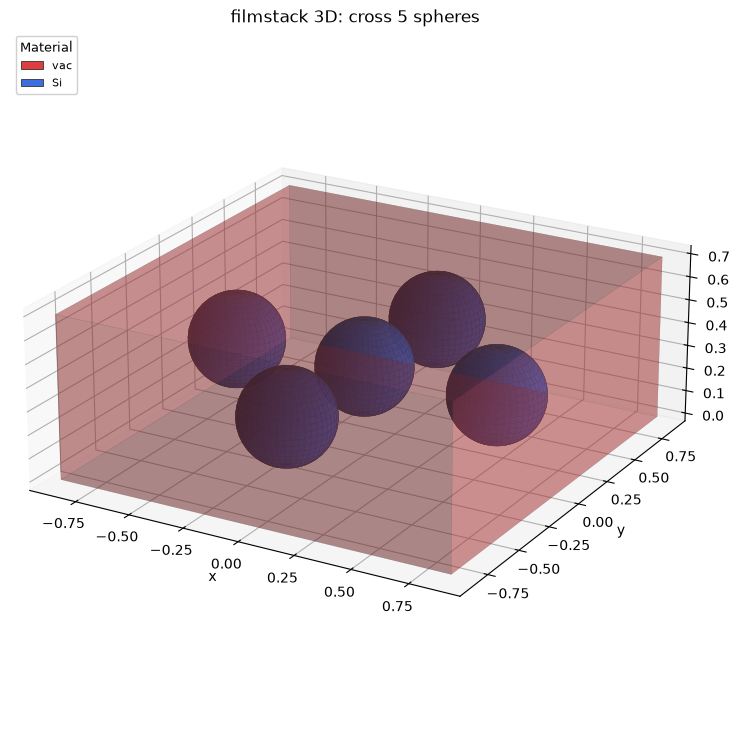

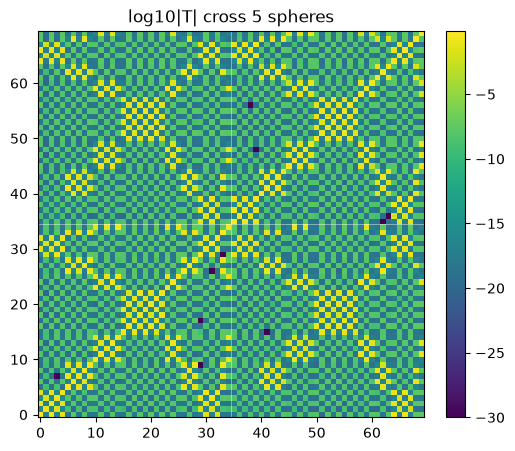

cross_5sph: max|T|=8.223e-01  shape=(70, 70)


In [7]:
rp = 0.2
centers_cross = [
    (0.0, 0.0, 0.0),
    (0.6, 0.0, 0.0),
    (-0.6, 0.0, 0.0),
    (0.0, 0.6, 0.0),
    (0.0, -0.6, 0.0),
]
shapes_cross = [
    simulation.make_sphere_shape_s(rp, [x, y, z], [0, 0, 0], _mat()) for x, y, z in centers_cross
]
lyr_cross = plot_cluster_layer(shapes_cross, "filmstack 3D: cross 5 spheres")
T_cross = np.asarray(
    simulation.compute_nfmds_tmatrix_layer_s(
        lyr_cross, CLUSTER_WL, CLUSTER_NRANK, CLUSTER_NRANKP
    )
)
plot_cluster_T(T_cross, "log10|T| cross 5 spheres", CLUSTER_NMAX)
print(f"cross_5sph: max|T|={float(np.max(np.abs(T_cross))):.3e}  shape={T_cross.shape}")


### 十字五球：对称性读图

- **不像单球那样几乎只有对角**：邻居球互相散射，非对角也会亮；白线分出的四大块里，交叉极化块也可能有结构。
- **“按 \(m\) 分块、块与块之间全黑”不再成立**：平面四邻破坏了绕 \(z\) 的连续旋转对称——相对前面单粒子各节，这是最醒目的差别。
- **仍有四重摆放**：绕 \(z\) 转 \(90^\circ\) 的对称还在，所以图案通常比随便乱放更整齐。
- **上下对称**：五球共面，图往往比后面真正的立体多球更“扁”一些。


### 平面六方柱

\(xy\) 平面上：中心一根圆柱，周围再围六根（轴都沿 \(z\)）。

仍是躺在一个平面上的团簇，不是“单个旋转体”。绕竖直轴转 \(60^\circ\) 大致不变。


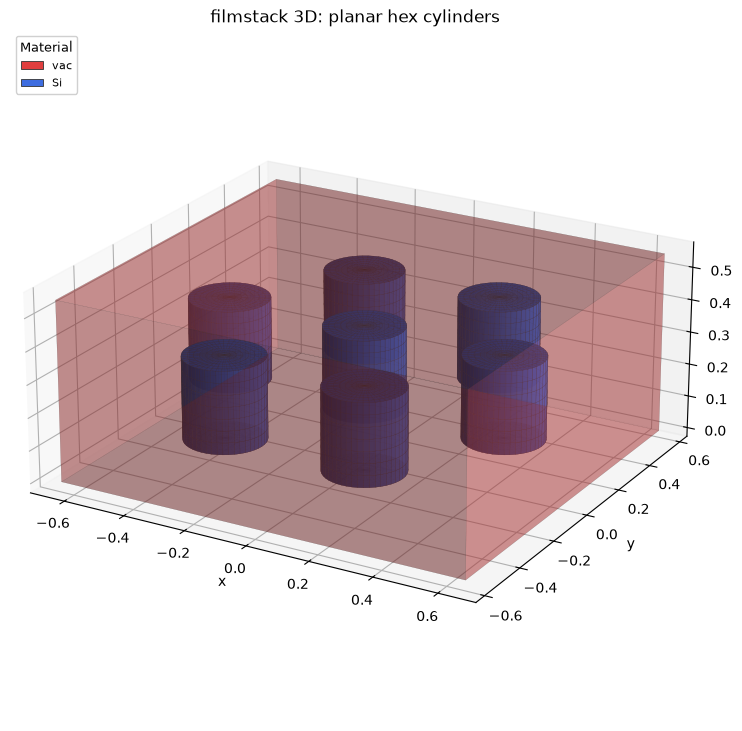

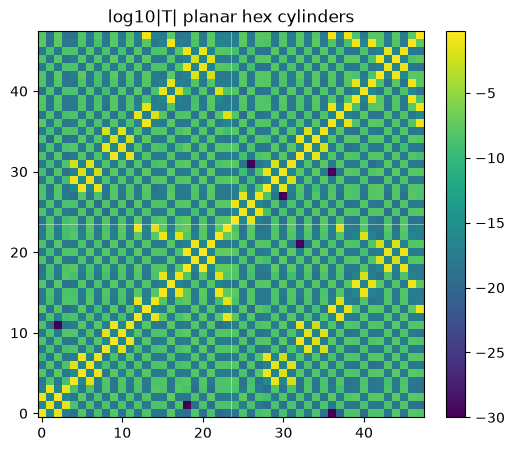

hex_cyl: max|T|=6.277e-01  shape=(48, 48)


In [8]:
r_cyl, h, d = 0.12, 0.25, 0.45
centers_hex = [(0.0, 0.0, 0.0)]
for i in range(6):
    ang = i * math.pi / 3.0
    centers_hex.append((d * math.cos(ang), d * math.sin(ang), 0.0))
shapes_hex = [
    simulation.make_finite_cylinder_shape_s(r_cyl, h, [x, y, z], [0, 0, 0], _mat())
    for x, y, z in centers_hex
]
lyr_hex = plot_cluster_layer(shapes_hex, "filmstack 3D: planar hex cylinders")
T_hex = np.asarray(
    simulation.compute_nfmds_tmatrix_layer_s(lyr_hex, CLUSTER_WL, 4, 3)
)
nmax_hex = nmax_from_nrank_mrank(4, 4)
plot_cluster_T(T_hex, "log10|T| planar hex cylinders", nmax_hex)
print(f"hex_cyl: max|T|={float(np.max(np.abs(T_hex))):.3e}  shape={T_hex.shape}")


### 平面六方柱：对称性读图

- **单根圆柱**若单独算，行为接近前面的旋转体；七根并排放后，整体只剩下“转 \(60^\circ\) 重复”这种离散对称，\(\lvert T\rvert\) 通常比十字五球更密、更“一圈圈”的感觉。
- **六重摆放**仍会约束哪些通道能亮：亮带往往成块、有规律，而不是均匀噪点。
- **共面 + 柱轴竖直**：上下对称还在；交叉极化图案和十字五球同类，只是角向周期更短（\(60^\circ\)）。


### 立方多球

边长参数 \(a=0.55\)，球半径 \(0.12\)。三种摆法：

- **只有 8 个顶点**各放一球
- **8 个顶点 + 立方体正中心**再放一球
- **8 个顶点 + 6 个面心**各放一球

这三种都是真正的立体团簇（上下左右前后都有邻居），不再摊在一个平面上。


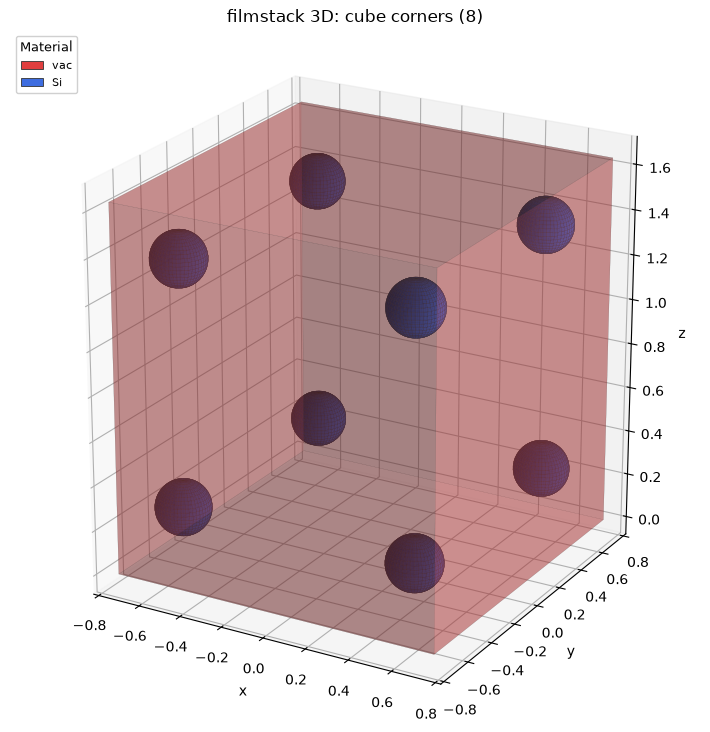

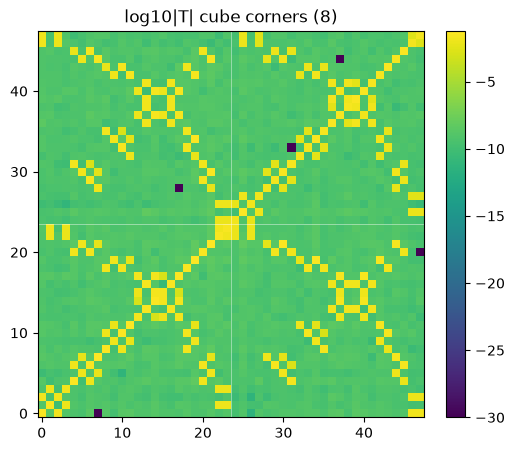

cube corners (8): max|T|=6.156e-02  n_sph=8


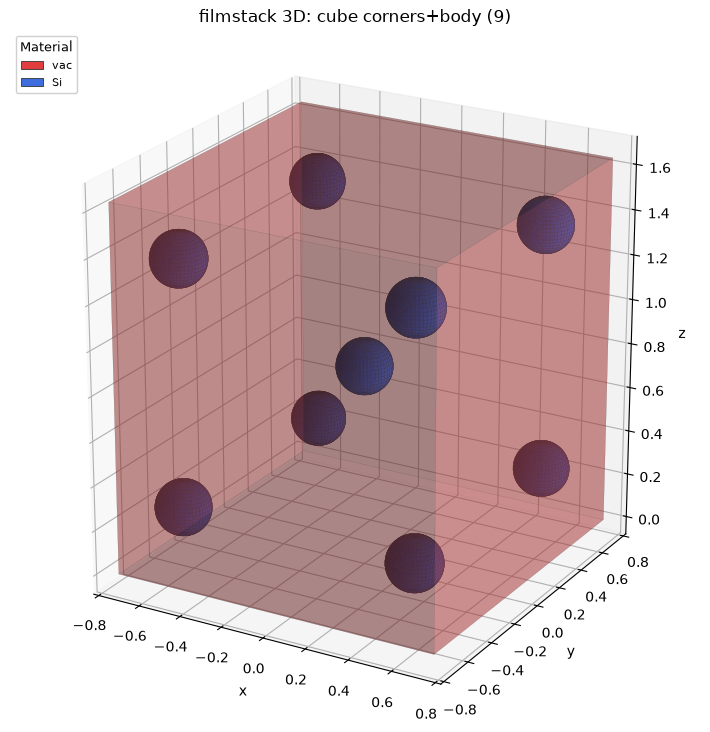

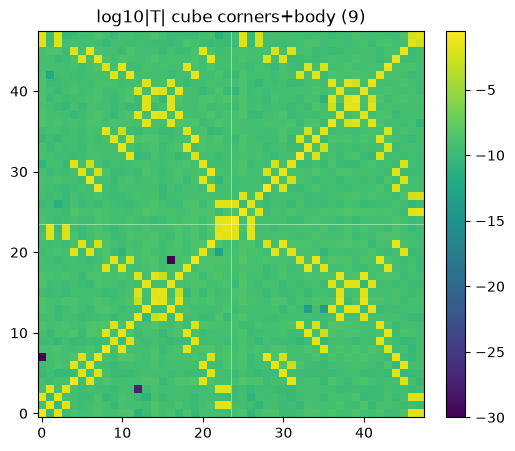

cube corners+body (9): max|T|=3.163e-01  n_sph=9


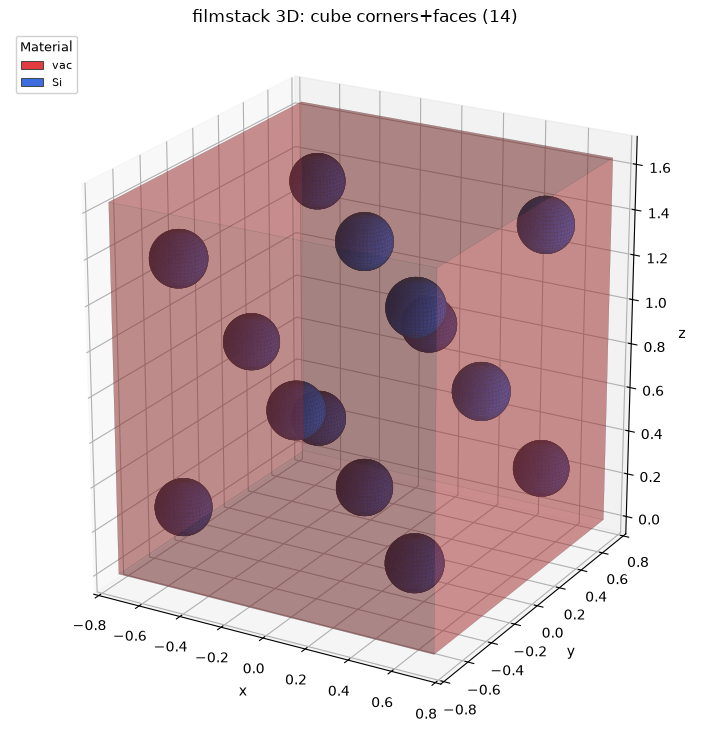

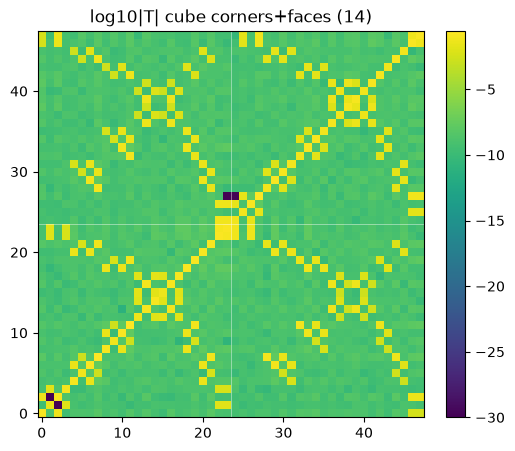

cube corners+faces (14): max|T|=2.905e-01  n_sph=14


In [9]:
a, rp = 0.55, 0.12
corners = [
    (sx * a, sy * a, sz * a)
    for sx in (-1, 1)
    for sy in (-1, 1)
    for sz in (-1, 1)
]
face = [(a, 0, 0), (-a, 0, 0), (0, a, 0), (0, -a, 0), (0, 0, a), (0, 0, -a)]


def _cube_case(centers, name):
    shapes = [
        simulation.make_sphere_shape_s(rp, [x, y, z], [0, 0, 0], _mat()) for x, y, z in centers
    ]
    lyr = plot_cluster_layer(shapes, f"filmstack 3D: {name}")
    T = np.asarray(
        simulation.compute_nfmds_tmatrix_layer_s(lyr, CLUSTER_WL, 4, 3)
    )
    nmax = nmax_from_nrank_mrank(4, 4)
    plot_cluster_T(T, f"log10|T| {name}", nmax)
    print(f"{name}: max|T|={float(np.max(np.abs(T))):.3e}  n_sph={len(shapes)}")
    return T


T_sc = _cube_case(corners, "cube corners (8)")
T_bcc = _cube_case(corners + [(0.0, 0.0, 0.0)], "cube corners+body (9)")
T_fcc = _cube_case(corners + face, "cube corners+faces (14)")


### 立方多球：对称性读图

- **相对平面十字/六方**：\(z\) 方向也有邻居，\(\lvert T\rvert\) 往往更满、更方，不那么“扁”。
- **顶点 → 加点心 → 再加面心**：球越来越多、靠得越密，整体亮度和非对角填充都会变；但立方摆放仍应让明暗成块、可辨，而不是碎成随机点。
- **对照单球**：单球几乎只亮对角、交叉极化整块发黑；这里对角可能还在，但团簇散射已打开大量非对角和交叉极化通道。
- 白线仍用来分 MM/NN 四大块；团簇情形下，不要再指望“不同 \(m\) 之间一片黑”。


## 9. 群论视角：对称性如何决定 T 的明暗

前面各节是“先算图、再口头读对称性”。这一节反过来：**先问几何有哪些不变操作，再预言 \(\lvert T\rvert\) 哪里该黑**，并对照已算好的图。

### 一句话机制

若某个操作（转动、镜像）让散射体看起来完全一样，则“入射 → 出射”的线性映射 \(T\) 必须与该操作相容。球矢量波按 \((\tau,l,m)\) 编号后，相容条件会变成：**某些行列交点必须严格为 0**。对数图上的黑格，多半就是这些被对称性关掉的通道；亮格则是对称性仍允许的耦合。

不必先背群名称。记住梯子即可：

**对称性越强 → 允许的亮格越少 → 图越“干净”。**

### 从强到弱（对照本笔记）

| 几何 | 大致有什么不变操作 | 图上该看到什么 |
|------|-------------------|---------------|
| 球 | 任意方向转动 | 近对角；交叉极化（白线外的两大块）整片接近黑 |
| 旋转椭球/圆柱等 | 绕 \(z\) 任意转；\(m=0\) 时还有额外极化解耦 | 不同 \(m\) 之间发黑；\(m=0\) 的交叉极化发黑 |
| 再加上下对称（完整椭球、双端截球） | 上面那条 + 对 \(z=0\) 翻面 | 同一 \(m\) 里奇偶阶之间发黑 → 棋盘格 |
| 一端截断 / 拱门 | 仍可绕 \(z\) 转，但上下不再对称 | \(m\) 规则还在；棋盘格被填亮 |
| 十字五球 / 平面六方柱 | 只能转离散角度（约 \(90^\circ\) / \(60^\circ\)），共面 | 不同 \(m\) 可以互相亮起来，但仍有规律，不是随机噪点 |
| 立方多球 | 立体摆放，立方体那套对称 | 比平面团簇更满、更方 |

下面把若干已算的 \(\lvert T\rvert\) 放在同一张图里，并给一个简单的“\(m\) 混杂度”数字：越接近 0，越像“不同 \(m\) 之间全黑”的旋转体；越大，说明离散摆放已经打开 \(m\leftrightarrow m'\) 通道。


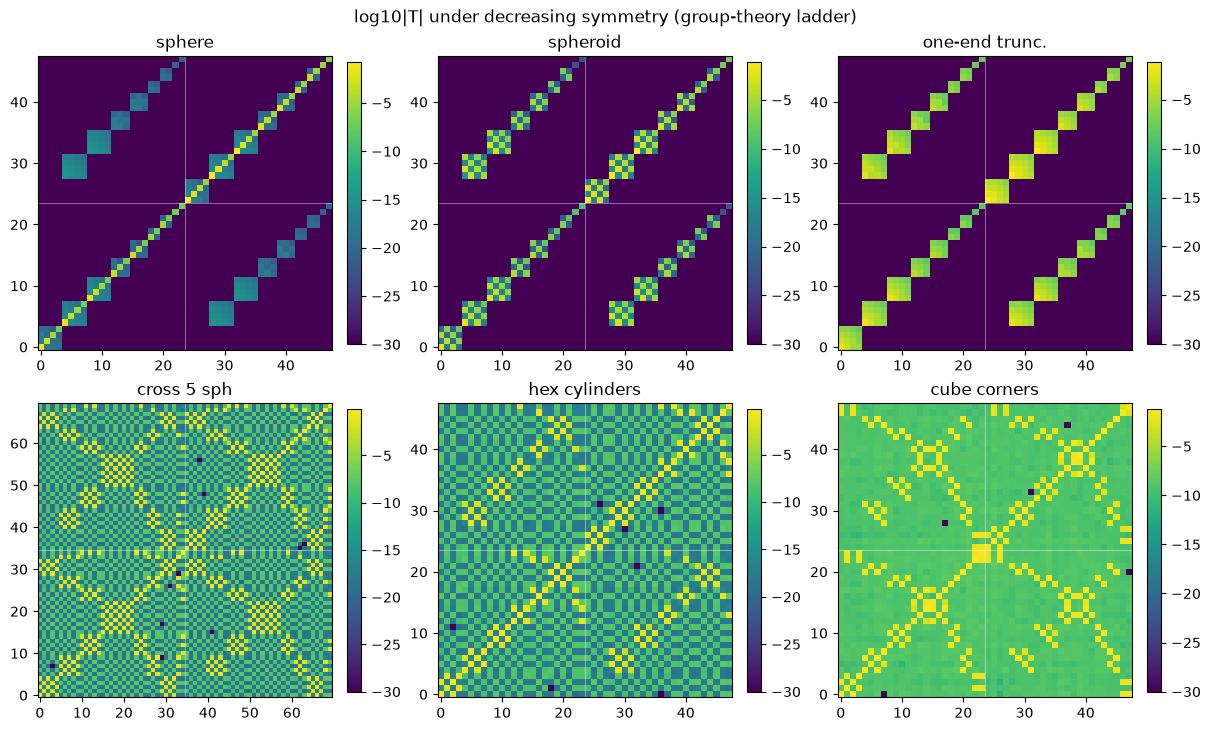

case                 m-mix   tau-mix  shape
sphere            0.000e+00  1.205e-14  (48, 48)
spheroid          0.000e+00  4.072e-02  (48, 48)
one-end trunc.    0.000e+00  9.216e-02  (48, 48)
cross 5 sph       4.426e-01  3.059e-01  (70, 70)
hex cylinders     1.732e-01  1.955e-01  (48, 48)
cube corners      4.428e-01  4.025e-01  (48, 48)


In [10]:
def _mode_meta(nrank: int, mrank=None):
    mrank = nrank if mrank is None else mrank
    nmax = nmax_from_nrank_mrank(nrank, mrank)
    meta = []
    for i in range(2 * nmax):
        tau, l, m = single_index_to_multi_nfmds(i, nrank, mrank)
        meta.append((tau, l, m))
    return nmax, meta


def m_mixing_ratio(T, nrank: int, mrank=None) -> float:
    # fraction of |T| mass coupling different m
    T = np.asarray(T)
    nmax, meta = _mode_meta(nrank, mrank)
    side = 2 * nmax
    if T.shape != (side, side):
        raise ValueError(f"T shape {T.shape} != {(side, side)}")
    A = np.abs(np.nan_to_num(T, nan=0.0, posinf=0.0, neginf=0.0))
    tot = float(A.sum())
    if tot < 1e-30:
        return 0.0
    mix = 0.0
    for i in range(side):
        for j in range(side):
            if meta[i][2] != meta[j][2]:
                mix += A[i, j]
    return mix / tot


def tau_mixing_ratio(T, nrank: int, mrank=None) -> float:
    # fraction of |T| mass in cross-pol blocks (M/N)
    T = np.asarray(T)
    nmax, meta = _mode_meta(nrank, mrank)
    side = 2 * nmax
    A = np.abs(np.nan_to_num(T, nan=0.0, posinf=0.0, neginf=0.0))
    tot = float(A.sum())
    if tot < 1e-30:
        return 0.0
    mix = 0.0
    for i in range(side):
        for j in range(side):
            if meta[i][0] != meta[j][0]:
                mix += A[i, j]
    return mix / tot


cases = [
    ("sphere", Te_sph, NRANK, NRANK),
    ("spheroid", Te_ell, NRANK, NRANK),
    ("one-end trunc.", Te_tse, NRANK, NRANK),
    ("cross 5 sph", T_cross, CLUSTER_NRANK, CLUSTER_NRANK),
    ("hex cylinders", T_hex, 4, 4),
    ("cube corners", T_sc, 4, 4),
]

fig, axes = plt.subplots(2, 3, figsize=(12.0, 7.2), constrained_layout=True)
for ax, (name, T, nr, mr) in zip(axes.ravel(), cases):
    A = np.abs(np.nan_to_num(T, nan=0.0, posinf=0.0, neginf=0.0))
    L = np.log10(np.maximum(A, LOG_FLOOR))
    nmax = nmax_from_nrank_mrank(nr, mr)
    im = ax.imshow(L, origin="lower", aspect="equal")
    ax.axhline(nmax - 0.5, color="w", lw=0.6, alpha=0.5)
    ax.axvline(nmax - 0.5, color="w", lw=0.6, alpha=0.5)
    ax.set_title(name)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("log10|T| under decreasing symmetry (group-theory ladder)")
plt.show()

print(f"{'case':16s}  {'m-mix':>8s}  {'tau-mix':>8s}  shape")
for name, T, nr, mr in cases:
    print(
        f"{name:16s}  {m_mixing_ratio(T, nr, mr):8.3e}  "
        f"{tau_mixing_ratio(T, nr, mr):8.3e}  {np.asarray(T).shape}"
    )


### 读这张对照图

- **sphere → spheroid**：球几乎只剩对角；拉成旋转椭球后，同 \(m\) 块内开始变“胖”，但不同 \(m\) 之间仍应接近黑——这是“绕 \(z\) 任意转”留下的选择定则。`m-mix` 应仍很小。
- **spheroid → one-end trunc.**：上下对称被破坏，块内棋盘格变糊；若仍是旋转体，`m-mix` 仍应小，但交叉极化（`tau-mix`）与块内填充会变。
- **cross / hex**：连续旋转对称没了，只剩离散转角。`m-mix` 会明显变大——图上再也不是干净的 \(m\)-块棋盘，但仍能看出有组织的亮带（四重 / 六重摆放的痕迹）。
- **cube corners**：立体邻居让图案更满；对称性换成立方体那一套，不再用“绕单一 \(z\) 轴”来读。相对平面十字，往往更方、更不“扁”。

### 使用时的两点提醒

1. **图上的“接近黑”不是数学上的精确 0**：有截断阶数、数值误差；看数量级和相对对比即可。
2. **群论管的是“谁必须为 0”**，不管“亮格有多亮”。亮度还跟折射率、尺寸、波长有关；对称性只负责关掉通道。

若只记住一件事：看到 \(\lvert T\rvert\) 图时，先数几何有哪些不变操作，再核对这些操作是否关掉了你预期的那批格子。
